In [1]:
import sys
import os
import glob
sys.path.insert(0,'..')
import simulacra.star
import simulacra.tellurics
from simulacra.star import PhoenixModel

import random
import numpy as np
import jax.numpy as jnp
import jax

import astropy.io.fits
import astropy.time as at

import astropy.units as u
import astropy.coordinates as coord
import astropy.constants as const

/scratch/mdd423/.conda/envs/wobbleenv/lib/python3.9/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/scratch/mdd423/.conda/envs/wobbleenv/lib/python3.9/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/scratch/mdd423/.conda/envs/wobbleenv/lib/python3.9/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


<h1>Imitating HARPS data</h1>
In this notebook, I will try to exactly imitate some data, pulled from the HARPS online archive of HD4307.

In [2]:
files_sci = glob.glob('/scratch/mdd423/wobble_jax/data/HD4307_harps/archive-8/*s1d_A*')
tbl = astropy.io.fits.open(files_sci[0])

In [3]:
tbl[0].header['*RV*'],tbl[0].header

(CRVAL1  =              3781.16 / Coordinate at reference pixel                  
 HIERARCH ESO DRS BERV = -28.4903658517236 / Barycentric Earth Radial Velocity   
 HIERARCH ESO DRS BERVMX = 30.7133361117053 / Maximum BERV                       ,
 SIMPLE  =                    T / file does conform to FITS standard             
 BITPIX  =                  -32 / number of bits per data pixel                  
 NAXIS   =                    1 / number of data axes                            
 NAXIS1  =               313106 / length of data axis 1                          
 EXTEND  =                    T / FITS dataset may contain extensions            
 COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
 COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
 CRPIX1  =                   1. / Reference pixel                                
 CRVAL1  =              3781.16 / Coordinate at reference pixel                  
 CDELT1  =     

In [4]:
ccftbl = astropy.io.fits.open(glob.glob('/scratch/mdd423/wobble_jax/data/HD4307_harps/archive-8/*{}*ccf*'.format(tbl[0].header['DATE-OBS']))[0])

In [5]:
all_snrs = tbl[0].header['*SN*']

ra = tbl[0].header['RA'] * u.deg
dec = tbl[0].header['DEC'] * u.deg
obs = 'lasilla'
loc = coord.EarthLocation.of_site(obs)
target = coord.SkyCoord(ra,dec,frame='icrs')
airmass_det = tbl[0].header['AIRMASS']

In [6]:
avg_snr = 0
for key in all_snrs.keys():
    avg_snr += all_snrs[key]
avg_snr /= len(all_snrs)
print(avg_snr)

112.11111111111109


In [7]:
def correct_wavelength(wavelengths,bcs):
        return  wavelengths * (1 + bcs/const.c)

epoches = 1
grid_size = tbl[0].header['NAXIS1']
wave_grid = np.linspace(tbl[0].header['CRVAL1'],\
                        tbl[0].header['CRVAL1'] + (grid_size*tbl[0].header['CDELT1']),\
                        grid_size) * u.Angstrom
berv = (tbl[0].header['HIERARCH ESO DRS BERV'])* u.km/u.s
rvc  = ccftbl[0].header['HIERARCH ESO DRS CCF RVC'] * u.km/u.s
rvs  = ccftbl[0].header['HIERARCH ESO DRS CCF RV'] * u.km/u.s

wave_grid = correct_wavelength(wave_grid,-berv)
# indices = (wave_grid > 6400*u.Angstrom) * (wave_grid < 6700*u.Angstrom)
# wave_grid = wave_grid[indices]

In [8]:
np.sum(np.diff(wave_grid < 0))

0

In [9]:
import astropy.time as atime
obs_times = atime.Time(np.array([tbl[0].header['DATE-OBS']]),)

<h2>Tellurics Model</h2>
The tellurics model requires these airmasses at the time of observation. However each of the pressure, temperatures, and humidities can be set by the user after initialization. If a single value is passed that is used for every epoch. Or you can pass it an array of quantities of size equal to the number of epoches.

In [10]:
wave_padding = 10*u.nm
tellurics_model = simulacra.tellurics.TelFitModel(loc,wave_grid.min(),wave_grid.max(),wave_padding=wave_padding)

In [11]:
class Resolution:
    def __init__(self,x_min,x_max,high_res,low_res):
        self.x_mean = (x_max + x_min) / 2
        self.a = (low_res - high_res) / ((x_min - x_max)/2)**2
        self.b = high_res
    def __call__(self,x):
        return self.a * (x - self.x_mean)**2 + self.b

In [12]:
resolution_func = Resolution(np.log((wave_grid.min() - wave_padding).to(u.Angstrom).value),\
                             np.log((wave_grid.max() + wave_padding).to(u.Angstrom).value),\
                            115_000,110_000)

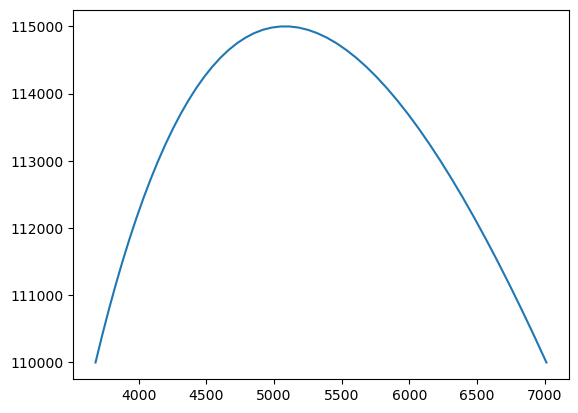

In [13]:
import matplotlib.pyplot as plt
x_space = np.linspace(np.log((wave_grid.min() - wave_padding).to(u.Angstrom).value),\
                             np.log((wave_grid.max()+ wave_padding).to(u.Angstrom).value))
plt.plot(np.exp(x_space),resolution_func(x_space))
plt.show()

Define some atmospheric parameters for the tellurics. These can either be constant over all time or an array with the same length as the number of epoches.

In [14]:
tellurics_model.pressure    = np.array([770]) * u.hPa
tellurics_model.humidity    = np.array([tbl[0].header['HIERARCH ESO TEL AMBI RHUM']])
tellurics_model.temperature = (np.array([tbl[0].header['HIERARCH ESO TEL AMBI TEMP']]) * u.Celsius).to(u.Kelvin,u.temperature())

<h2>Star Model</h2>
The model in the simulacra package pulls baryocentric radial velocities and injects a planet but here will exactly set the radial velocity of the star to the HARPS pipeline RV.

try another example! load in g2 mask!

In [15]:
g2mask = np.fromfile('../data/G2.harps.mas',sep=' ')
g2mask = np.array((g2mask[::2],g2mask[1::2]))
ccftbl[0].header['HIERARCH ESO DRS CCF RVC']

-10.2775831867808

In [16]:
# this_rv = -(tbl[0].header['HIERARCH ESO DRS BERV'] - 93)
this_rv = (berv - rvc).to(u.km/u.s).value
class RVStar(PhoenixModel):
    def get_velocity(self,detector,obs_times):
        return np.array([this_rv]) * u.km/u.s

In [17]:
import astropy.constants as const

In [18]:
# temp_grid = np.concatenate((np.arange(2300,7000,100),np.arange(7000,12200,200)))
# logg_grid = np.arange(0.0,6.5,0.5)
# zzz__grid = np.concatenate((np.arange(-4,-2,1),np.arange(-2,1.5,0.5)))
# alph_grid = np.arange(-0.2,1.4,0.2)
# print(logg_grid,zzz__grid,alph_grid)

Here we kinda have to guess what the stellar parameters of the star are because...

In [19]:
logg = 4.0
T    = 6000
z    = 0.0
alpha= -0.2

distance  = 31.86 * u.pc
amplitude = None
period    = None
stellar_model = RVStar(distance,alpha,z,T,logg,target,amplitude,period)

using saved wave file
your parameters: T 6000, logg 4.0, alpha -0.2, z 0.0
setting: T 6000, logg 4.0, alpha -0.2, z 0.0
../data/stellar/PHOENIX/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.0.Alpha=-0.20/lte06000-4.00-0.0.Alpha=-0.20.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
using saved flux file
reading in ../data/stellar/PHOENIX/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits


In [21]:
from simulacra.detector import Detector

<h2>Detector</h2>
Here we define our detector giving it an aperature area, resolution, dark current, read noise, and ccd efficiency. All of these can be except area can be given as an array of the same size as the wave_grid (eg. if the detector has varying resolution or noise levels)

In [22]:
avg_snr

112.11111111111109

In [23]:
resolution = resolution_func
area = np.pi*(4.3 * u.m/2)**2
# exp_times = [100,500] * u.second 
snrs = [avg_snr] * epoches
through_put  = 1e-6

detector = Detector(stellar_model,resolution,loc,area,wave_grid,through_put,wave_padding)

In [24]:
detector.add_model(tellurics_model)

<h2>Simulator</h2>
Now comes the bulk of the work, run the simulation with the given transmission models, star, detector at the given times for some exposure times.

In [25]:
data = detector.simulate(obs_times,snrs=snrs)

surface flux: mean 4.47e+14 erg / (s cm3)	 median 3.54e+14 erg / (s cm3)
obs     flux: mean 7.97e-04 erg / (s cm3)	 median 6.31e-04 erg / (s cm3)
generating spectra...
humidity: 34.0
 pressure: 770.0
 temperature: 285.75
 lat: -29.25666666666666
 elevation: 2.3469999999988422
 freqmin(cm-1): 14259.48316511964
 freqmax(cm-1): 27162.698559010765
 angle: 34.4439641013701


Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
1.35user 1.16system 0:03.51elapsed 71%CPU (0avgtext+0avgdata 7268maxresident)k
998inputs+0outputs (8major+1227minor)pagefaults 0swaps



Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
1.17user 1.14system 0:02.91elapsed 79%CPU (0avgtext+0avgdata 7548maxresident)k
0inputs+0outputs (0major+1232minor)pagefaults 0swaps



Running exec: lblrtm




...


Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
0.69user 0.98system 0:01.78elapsed 94%CPU (0avgtext+0avgdata 7372maxresident)k
0inputs+0outputs (0major+1194minor)pagefaults 0swaps


3104389
<simulacra.tellurics.TelFitModel object at 0x154044a92eb0> [1.0000006209764933e-06, 1.9233706538557271e-07]
interpolating spline...
combining grids...
convolving...
batches 34
47.104103 1.9233706538557271e-07 9.059865e-06
building convolving matrix...
batch 0
47.104103 1.9233706538557271e-07 9.059865e-06
building convolving matrix...
batch 1
46.484314 1.9233706538557271e-07 8.940657e-06
building convolving matrix...
batch 2
46.484314 1.9233706538557271e-07 8.940657e-06
building convolving matrix...
batch 3
46.484314 1.9233706538557271e-07 8.940657e-06
building convolving matrix...
batch 4
46.484314 1.9233706538557271e-07 8.940657e-06
building convolving matrix...
batch 5
45.864525 1.9233706538557271e-07 8.821448e-06
building convolving matrix...
batch 6
45.864525 1.9233706538557271e-07 8.821448e-06
building convolving matrix...
batch 7
45.864525 1.9233706538557271e-07 8.821448e-06
building convolving matrix...
batch 8
45.864525 1.9233706538557271e-07 8.821448e-06
building convo

/home/mdd423/WobbleSim/notebooks/../simulacra/detector.py:615: OptimizeWarning: Unknown solver options: gtol
  res = scipy.optimize.minimize(
/home/mdd423/WobbleSim/notebooks/../simulacra/detector.py:642: UserWarning: Explicitly requested dtype float64  is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return f + jax.random.normal(PRNG_KEY, shape=f.shape, dtype=f.dtype) * err


generating errors...
t_exp: 5696.690675375306 min
snr: 107.7429156018997
done.


In [26]:
# filename = '/scratch/mdd423/simulacra/out/HD4307_{}_fake.h5'.format(tbl[0].header['DATE-OBS'])
# data.to_h5(filename)

In [27]:
# with h5py.File(filename,"r") as hf:
#     print(hf['data']['flux'])

In [28]:
import matplotlib.pyplot as plt
import scipy.ndimage
def lin_normalize(y):
    y_min, y_max = y.min(), y.max()
    
    return (y - y_min)/(y_max - y_min)

def err_lin_normalize(yerr,y):
    y_min, y_max = y.min(), y.max()
    return yerr / (y_max - y_min)

In [29]:
guess_vel = -berv+rvs
# print((guess_vel/const.c).to(1).value)
print(correct_wavelength(g2mask[0,0],guess_vel),g2mask[0,0])
print(berv,rvs,rvc,stellar_model.get_velocity(None,None),guess_vel)

3750.5206945689742 3750.292858
-28.4903658517236 km / s -10.2774721867808 km / s -10.2775831867808 km / s [-18.21278266] km / s 18.212893664942797 km / s


In [30]:
import specutils

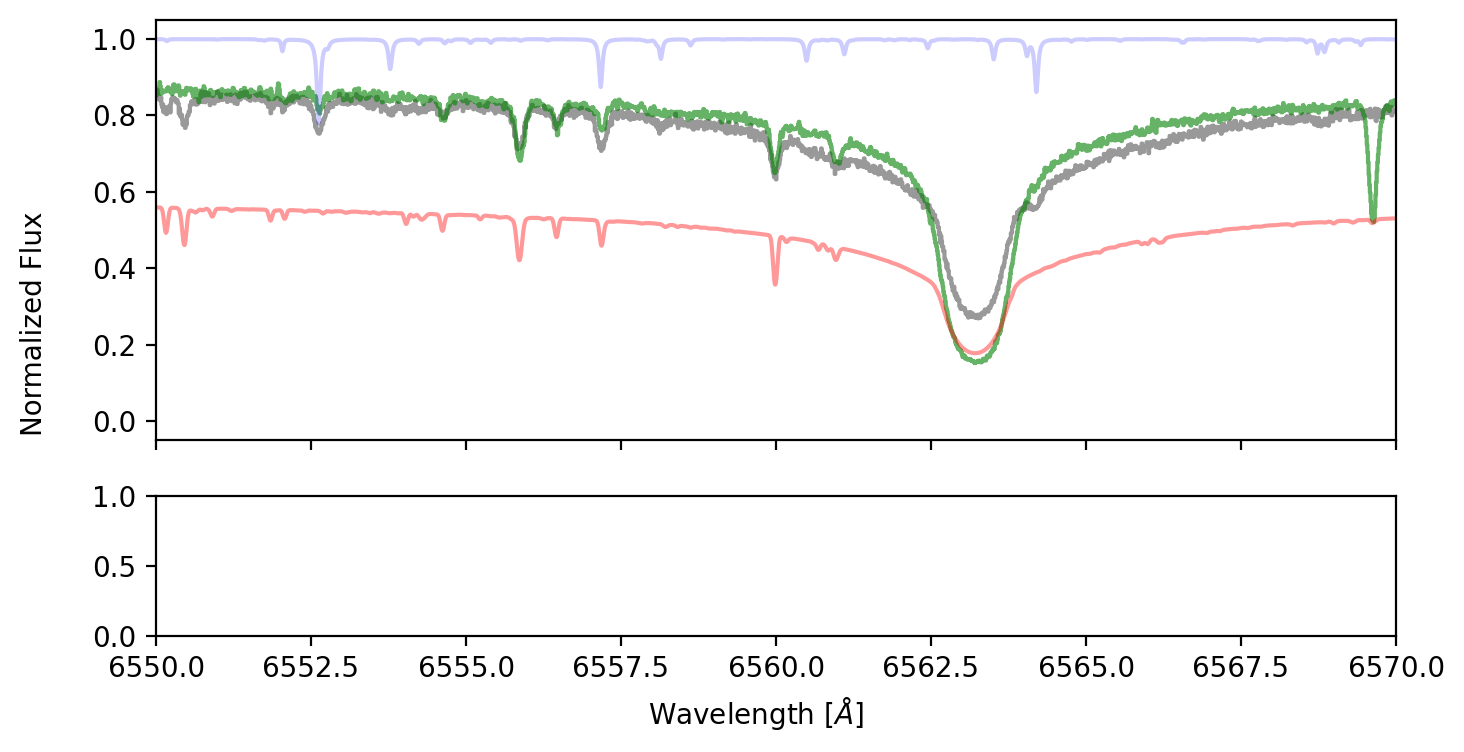

In [31]:
fig, axes = plt.subplots(2,figsize=(8,4),height_ratios=[3,1],dpi=200,sharex=True)

axes[0].step(data['data']['wave'][:].to(u.Angstrom).value,\
          lin_normalize(data['data']['flux'][0,:]),'k',where='mid',alpha=0.4)
# axes.plot(data['data']['wave'][:].to(u.Angstrom).value,\
#           (data['data']['flux_expected'][0,:]),'.m',alpha=0.4)

axes[0].vlines(g2mask[0,:],ymin=0.0,ymax=1.0)
# axes[0].plot(correct_wavelength(g2mask[0,:],guess_vel),1-g2mask[1,:],'.b')
# / specutils.utils.wcs_utils.refraction_index(wave_grid, method='Morton2000', co2=None)
axes[0].step(wave_grid.to(u.Angstrom).value ,lin_normalize(tbl[0].data),'g',where='mid',alpha=0.6)

axes[0].plot(data['theory']['total']['wave'][:].to(u.Angstrom).value,\
          lin_normalize(data['theory']['star']['flux'][0,:]),'r',alpha=0.4)
# axes.plot(data['theory']['total']['wave'][:].to(u.Angstrom).value,\
#           lin_normalize(data['theory']['lsf']['flux'][0,:]),'m',alpha=0.1)
axes[0].plot(data['theory']['total']['wave'][:].to(u.Angstrom).value,\
          data['theory']['tellurics']['flux'][0,:],'b',alpha=0.2)

# axes[1].step(wave_grid.to(u.Angstrom).value,\
#           lin_normalize(tbl[0].data[indices]),'g',where='mid',alpha=0.6)

axes[0].set_xlim(6550,6570)
fig.text(0.5, 0.00, 'Wavelength [$\AA$]', ha='center')
fig.text(0.04, 0.5, 'Normalized Flux', va='center', rotation='vertical')
plt.savefig('../out/HD4307_w_g2mask.png',bbox_inches='tight')
plt.show()

In [32]:
g2mask[0,:]

array([3750.292858, 3750.679384, 3750.872722, ..., 6793.262511,
       6795.801624, 6798.466703])

In [33]:
import matplotlib
matplotlib.rcParams['text.usetex'] = True

[3800.         3963.15789474 4126.31578947 4289.47368421 4452.63157895
 4615.78947368 4778.94736842 4942.10526316 5105.26315789 5268.42105263
 5431.57894737 5594.73684211 5757.89473684 5921.05263158 6084.21052632
 6247.36842105 6410.52631579 6573.68421053 6736.84210526 6900.        ] Angstrom
[3800.         3963.15789474 4102.         4289.47368421 4452.63157895
 4615.78947368 4778.94736842 4942.10526316 5105.26315789 5268.42105263
 5431.57894737 5594.73684211 5757.89473684 5921.05263158 6084.21052632
 6300.         6410.52631579 6563.         6736.84210526 6900.        ] Angstrom
(20,) (5, 4)


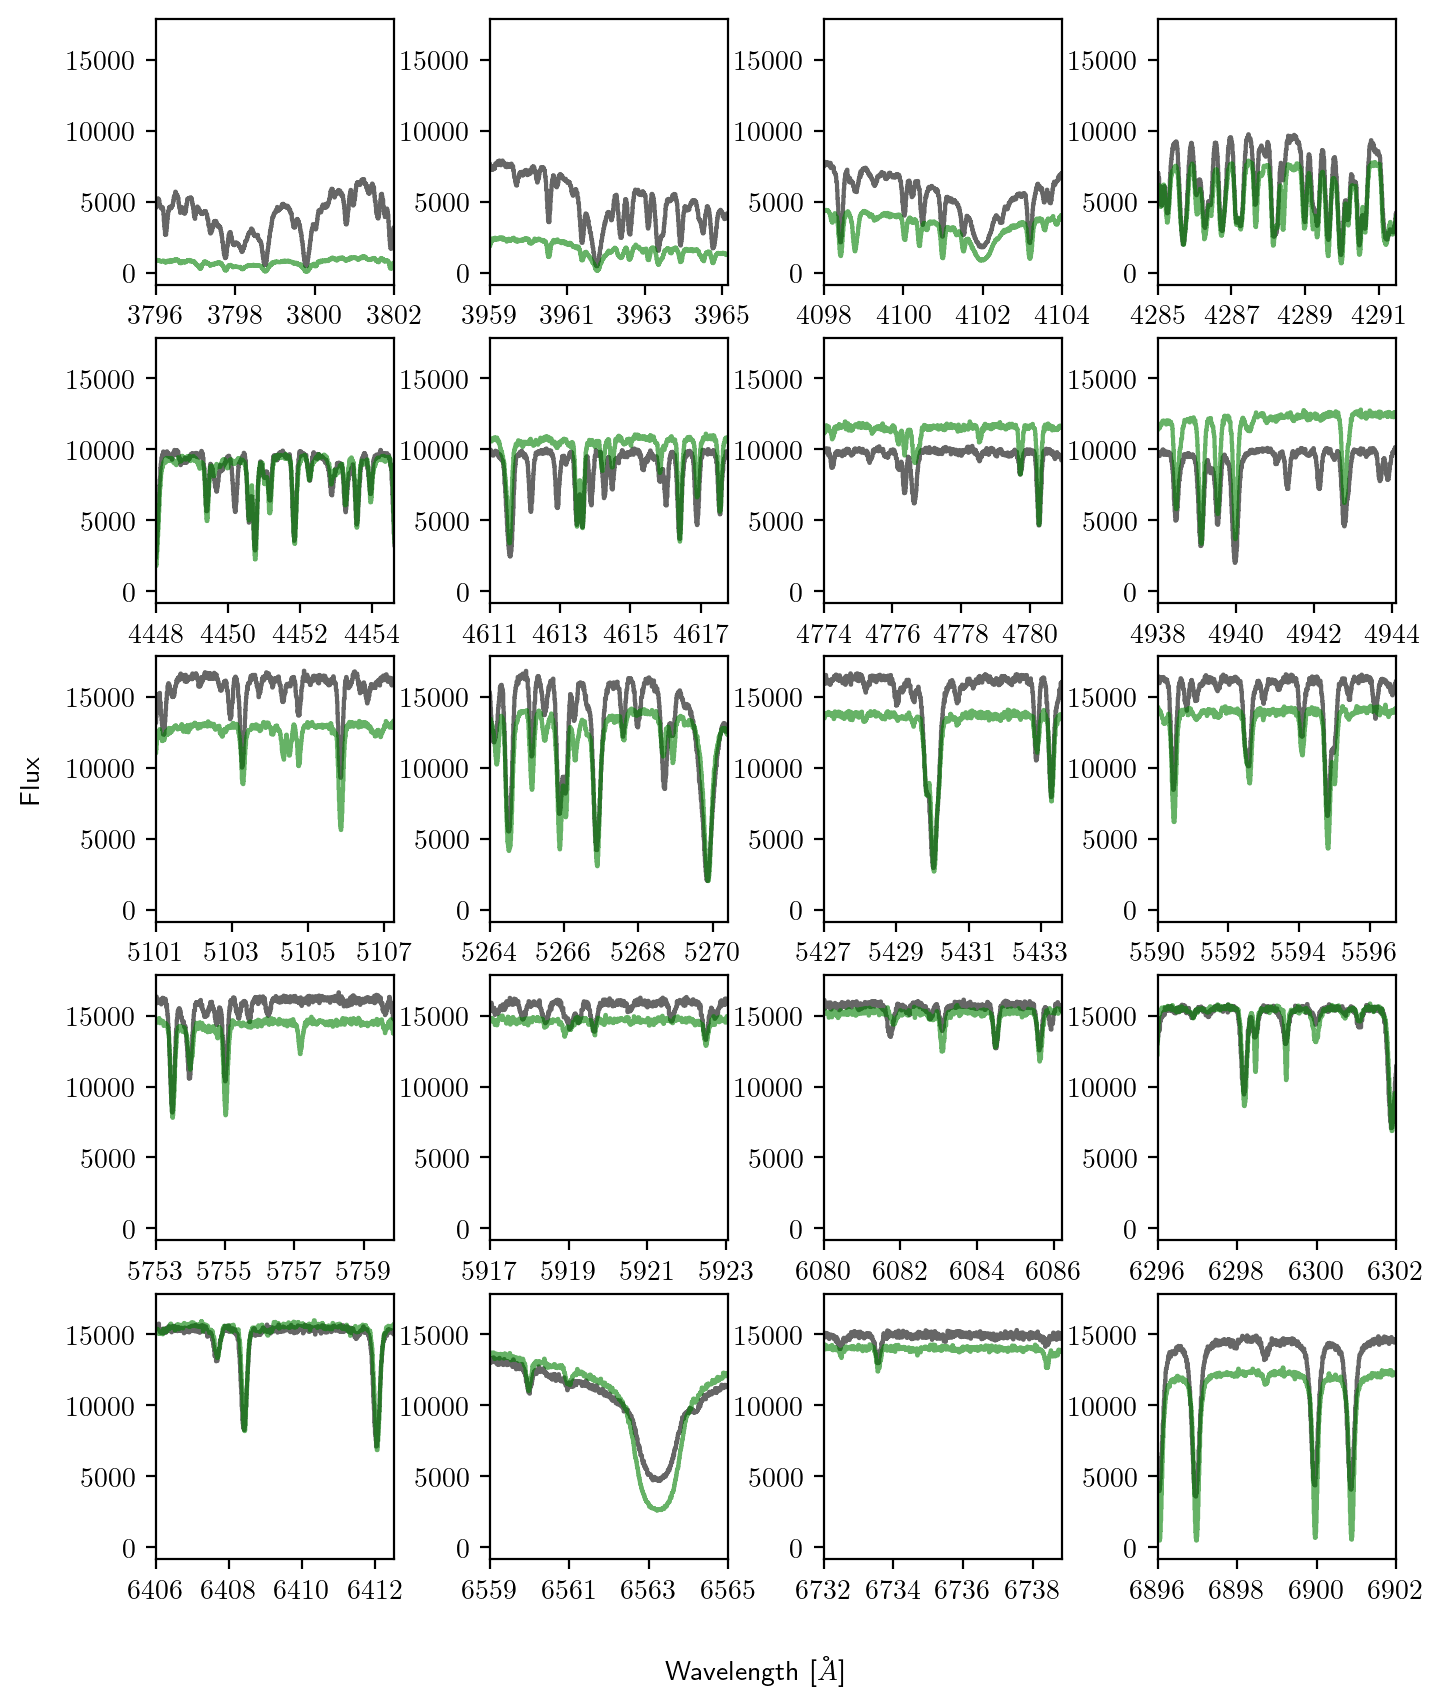

In [40]:
guess_vel = 0*u.km/u.s
iii_n = 4
jjj_n = 5
fig, axes = plt.subplots(jjj_n,iii_n,figsize=(8,10),dpi=200)

means_l = np.linspace(3800,6900,iii_n*jjj_n) * u.Angstrom

print(means_l)
means_l[2] = 4102 * u.Angstrom
means_l[15] = 6300 *u.Angstrom
means_l[17] = 6563 *u.Angstrom
# means_l[16] = 6868 *u.Angstrom
print(means_l)
width_l = np.arange(-4,4,2) * u.Angstrom

print(means_l.shape,axes.shape)
for jjj in range(jjj_n):
    for iii in range(iii_n):
        this_mean = means_l[(jjj * iii_n) + iii]
        axes[jjj,iii].step(data['data']['wave'][:].to(u.Angstrom).value,\
                  (data['data']['flux'][0,:]),'k',alpha=0.6,where='mid')
        
        axes[jjj,iii].step(wave_grid.to(u.Angstrom).value,\
                  (tbl[0].data[:]),'g',alpha=0.6,where='mid')
        
        # axes[jjj,iii].plot(data['theory']['total']['wave'][:].to(u.Angstrom).value,\
        #           (data['theory']['star']['flux'][0,:]),'r',alpha=0.2)
        # axes[jjj,iii].plot(data['theory']['total']['wave'][:].to(u.Angstrom).value,\
        #           data['theory']['tellurics']['flux'][0,:],'b',alpha=0.2)


        axes[jjj,iii].set_xlim((this_mean + np.min(width_l)).to(u.Angstrom).value,\
                               (this_mean + np.max(width_l)).to(u.Angstrom).value)
        axes[jjj,iii].set_xticks((int(this_mean.to(u.Angstrom).value)+width_l.to(u.Angstrom).value))
fig.text(0.5, 0.05, 'Wavelength [$\AA$]', ha='center')
fig.text(0.04, 0.5, 'Flux', va='center', rotation='vertical')
plt.subplots_adjust(wspace=0.4, hspace=None)
plt.savefig('../out/HD4307_sim.png',bbox_inches='tight')
plt.show()

In [35]:
from simulacra.dataset import print_keys
print_keys(data)

data: <class 'dict'>
--obs_times: <class 'astropy.time.core.Time'>
--epoches: <class 'int'>
--snrs: <class 'list'>
--wavelength_trigger: <class 'astropy.units.quantity.Quantity'>
--rvs: <class 'astropy.units.quantity.Quantity'>
--mask: <class 'numpy.ndarray'>
--t_exp: <class 'astropy.units.quantity.Quantity'>
--flux_expected: <class 'numpy.ndarray'>
--flux: <class 'numpy.ndarray'>
--wave: <class 'astropy.units.quantity.Quantity'>
--ferr: <class 'numpy.ndarray'>
theory: <class 'dict'>
--star: <class 'dict'>
----deltas: <class 'jaxlib.xla_extension.ArrayImpl'>
----flux: <class 'numpy.ndarray'>
--total: <class 'dict'>
----flux: <class 'numpy.ndarray'>
----wave: <class 'astropy.units.quantity.Quantity'>
----mask: <class 'numpy.ndarray'>
--tellurics: <class 'dict'>
----flux: <class 'numpy.ndarray'>
--lsf: <class 'dict'>
----flux: <class 'numpy.ndarray'>
parameters: <class 'dict'>
--wavetransform: <class 'NoneType'>
--star: <class 'dict'>
----_flux: <class 'numpy.ndarray'>
----_lambmax: <cla

[-18.21278266] km / s [-28.48265141] km / s


AttributeError: 'NoneType' object has no attribute 'to'

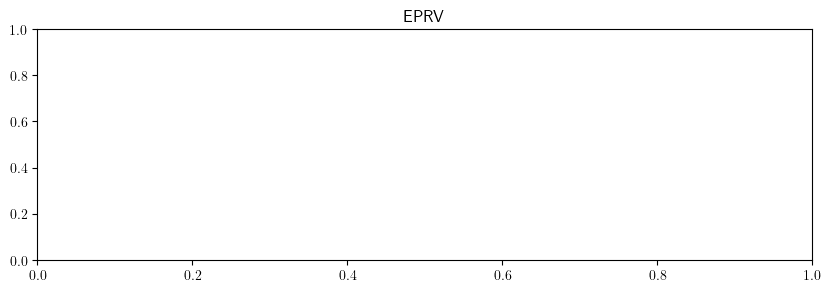

In [36]:
times = obs_times
rv = data['data']['rvs'].to(u.km/u.s)
bc  = [target.radial_velocity_correction(obstime=time,location=loc).to(u.km/u.s).value for time in times] * u.km/u.s
print(rv,bc)
eprv = rv - bc


plt.figure(figsize=(10,3))
plt.title('EPRV')
v_unit = u.m/u.s
plt.plot(([(time - min(times)).to(u.day).value % period.to(u.day).value for time in times]),eprv.to(v_unit).value,'.r')
plt.ylabel('vel [{}]'.format(v_unit))
plt.xlabel('time [d]')
plt.show()

plt.figure(figsize=(10,3))
plt.title('RV')
v_unit = u.km/u.s
plt.plot(([(time - min(times)).to(u.day).value for time in times]),rv.to(v_unit).value,'.k')
plt.ylabel('vel [{}]'.format(v_unit))
plt.xlabel('time [d]')
plt.show()